# Import Required Libraries

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Define physical structure

In [56]:
l1 = 2
l2 = 2
l3 = 1

x = float(input("Enter x-component of position of end-effector w.r.t. base: "))
y = float(input("Enter y-component of position of end-effector w.r.t. base: "))
phi_deg = float(input("Enter orientation of end-effector w.r.t. base: "))

# Inverse Kinematics

In [57]:
def inverse_kinematics_3R(x, y, phi_deg, l1, l2, l3):

    phi = np.radians(phi_deg)

    # Wrist point
    X = x - l3 * np.cos(phi)
    Y = y - l3 * np.sin(phi)

    D = (X**2 + Y**2 - l1**2 - l2**2) / (2 * l1 * l2)

    if abs(D) > 1:
        print("Target point is outside workspace!")
        return None

    solutions = []

    # Elbow-down and Elbow-up
    for theta2 in [np.arccos(D), -np.arccos(D)]:

        k1 = l1 + l2 * np.cos(theta2)
        k2 = l2 * np.sin(theta2)

        theta1 = np.arctan2(Y, X) - np.arctan2(k2, k1)
        theta3 = phi - theta1 - theta2

        solutions.append((theta1, theta2, theta3))

    return solutions



# Plot the Configuration


Elbow-Down Solution
θ1 = 90.00°
θ2 = 0.00°
θ3 = 540.00°


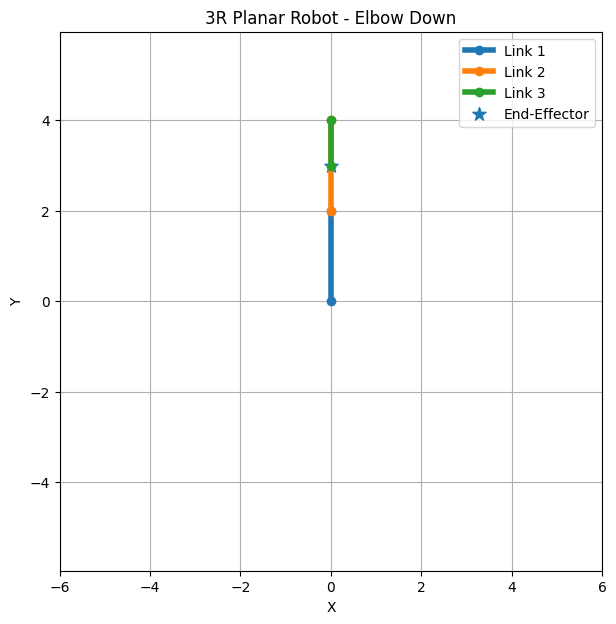


Elbow-Up Solution
θ1 = 90.00°
θ2 = -0.00°
θ3 = 540.00°


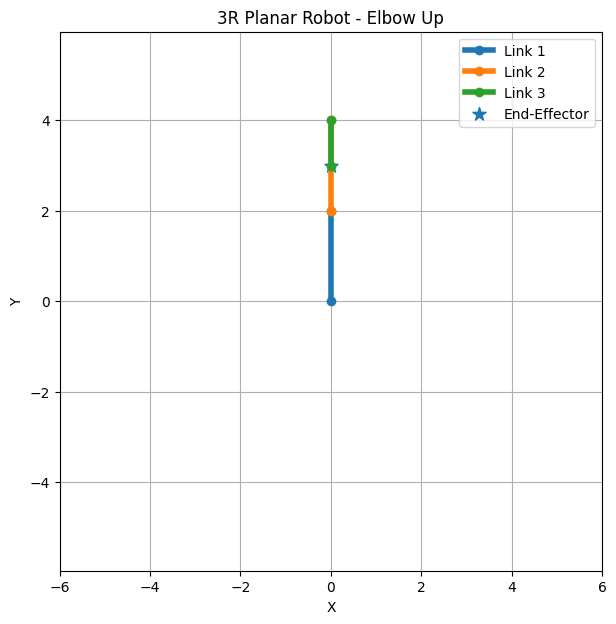

In [58]:
def plot_robot(theta1, theta2, theta3, l1, l2, l3, title):

    # Joint coordinates
    x0, y0 = 0, 0

    x1 = l1 * np.cos(theta1)
    y1 = l1 * np.sin(theta1)

    x2 = x1 + l2 * np.cos(theta1 + theta2)
    y2 = y1 + l2 * np.sin(theta1 + theta2)

    x3 = x2 + l3 * np.cos(theta1 + theta2 + theta3)
    y3 = y2 + l3 * np.sin(theta1 + theta2 + theta3)

    # Plot robot
    plt.figure(figsize=(7, 7))

    plt.plot([x0, x1], [y0, y1], 'o-', linewidth=4, label='Link 1')
    plt.plot([x1, x2], [y1, y2], 'o-', linewidth=4, label='Link 2')
    plt.plot([x2, x3], [y2, y3], 'o-', linewidth=4, label='Link 3')

    plt.scatter(x3, y3, s=100, marker='*', label='End-Effector')

    plt.grid(True)
    plt.axis('equal')

    L = l1 + l2 + l3 + 1
    plt.xlim(-L, L)
    plt.ylim(-L, L)

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(title)
    plt.legend()

    plt.show()

solutions = inverse_kinematics_3R(x, y, phi_deg, l1, l2, l3)

if solutions:

    # Elbow-Down
    t1, t2, t3 = solutions[0]
    print("\nElbow-Down Solution")
    print(f"θ1 = {np.degrees(t1):.2f}°")
    print(f"θ2 = {np.degrees(t2):.2f}°")
    print(f"θ3 = {np.degrees(t3):.2f}°")

    plot_robot(t1, t2, t3, l1, l2, l3,
               "3R Planar Robot - Elbow Down")

    # Elbow-Up
    t1, t2, t3 = solutions[1]
    print("\nElbow-Up Solution")
    print(f"θ1 = {np.degrees(t1):.2f}°")
    print(f"θ2 = {np.degrees(t2):.2f}°")
    print(f"θ3 = {np.degrees(t3):.2f}°")

    plot_robot(t1, t2, t3, l1, l2, l3,
               "3R Planar Robot - Elbow Up")